<a href="https://colab.research.google.com/github/Jhoniisjelly/Data201_JhonathanUrquilla/blob/main/Week5Assignment_JUrquilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 --- Week 5 Assignment
### Jhonathan Urquilla

## Resampling Methods with the Iris Dataset

In this assignment, we will explore **bootstrap resampling, jackknife
resampling, and permutation tests** using the **Iris dataset**.

The Iris dataset contains measurements of iris flowers from three
species:

-   *Setosa*
-   *Versicolor*
-   *Virginica*

Each flower has four measurements:

-   sepal length
-   sepal width
-   petal length
-   petal width

# Load the Dataset

Use the following code to load the dataset.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Tasks

1.  Print the **number of observations** in the dataset.

In [ ]:
print(len(iris))

150


2.  Print the **column names**.

In [ ]:
print(iris.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


3.  Count how many observations exist for each **species**.

In [ ]:
print(iris["species"].value_counts)

<bound method IndexOpsMixin.value_counts of 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object>


# Part 1 --- Bootstrap Resampling

## Task 1 --- Basic Statistics

Compute the following statistics for **sepal length**:

-   mean

In [ ]:
print(np.mean(iris["sepal_length"]))

5.843333333333334


-   median

In [ ]:
print(np.median(iris["sepal_length"]))

5.8


-   standard deviation

In [ ]:
print(np.std(iris["sepal_length"]))

0.8253012917851409


## Task 2 --- Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:

1.  Sample the dataset **with replacement**.
2.  Each sample must contain **150 observations**.
3.  Compute the **mean sepal length** for each resample.
4.  Store the results.

Plot the **distribution of bootstrap means**.

**Note on Efficiency**

While 5,000 iterations is manageable for 150 rows, consider the
computational cost if our dataset had **1 million rows**.
If your computer feels slow, try **1,000 iterations first**.

Bootstrapped Mean: 5.89
Bootstrapped Std: 0.0655


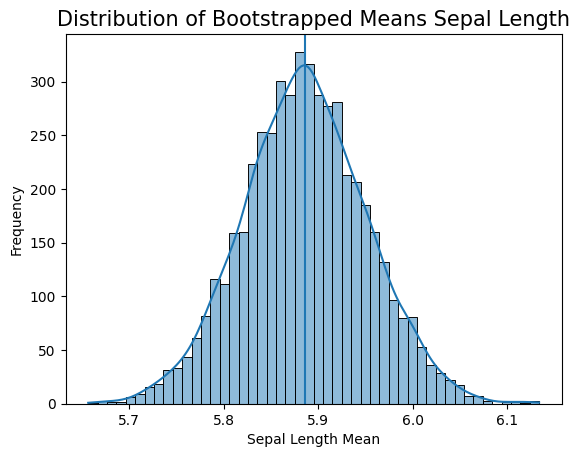

In [ ]:
n_bootstrap = 5000
sample_n = 150
sample = np.random.choice(iris["sepal_length"], size=sample_n, replace=True)

bootstrap_means = []

for b in range(n_bootstrap):
  bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means Sepal Length', fontsize=15)
plt.ylabel('Frequency', fontsize=10)
plt.xlabel('Sepal Length Mean', fontsize=10)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_means):.3}')

## Task 3 --- Confidence Interval

Using the bootstrap results, compute the **95% confidence interval**
using the percentile method:

CI = \[2.5%, 97.5%\]

Report:

-   Bootstrap mean
-   Lower bound
-   Upper bound

In [ ]:
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

Bootstrapped Mean: 5.89
95% Confidence Intervals: [5.76, 6.02]


### Question

Why is it mathematically necessary to sample **with replacement** in
bootstrap resampling?


Sampling with replacement introduces enough variation to simulate a lot of different samples, which helps approximate the statistic's distribution and it allows us to build a more reliable confidence interval.

# Part 2 --- Jackknife Resampling

## Task 4 --- Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:

1.  For each observation i, remove it from the dataset.
2.  Compute the mean of the remaining observations.
3.  Store the result.

Plot the **distribution of jackknife means**.

In [ ]:
def jackknife_resampling(sample):
    n = sample_n
    jackknife_means = np.zeros(n)

    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    jackknife_mean = np.mean(jackknife_means)

    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)

    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")


Jackknife Mean: 5.884000000000001
Bias: 0.0
Variance: 0.004385753914988821


Text(0.5, 0, 'Mean Sepal Length')

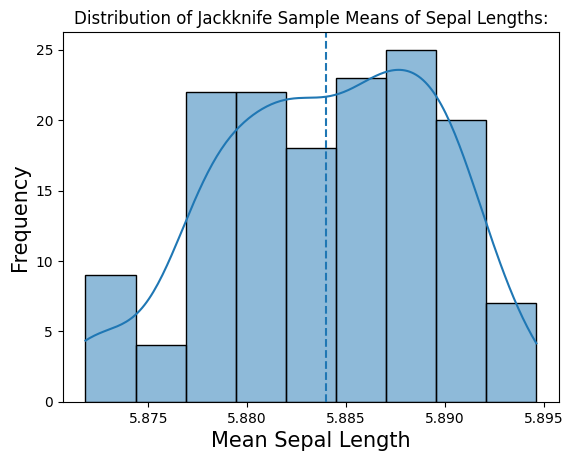

In [ ]:
sns.histplot(jackknife_means, kde=True)
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means of Sepal Lengths:')
plt.ylabel('Frequency', fontsize=15)
plt.xlabel("Mean Sepal Length", fontsize=15)

### Question

If the dataset contains n observations, **exactly how many jackknife
samples** are created?

If the dataset contains **n** observations then **n** will be created. In this case, n was 150 observations so 150 were created

# Part 3 --- Permutation Test

We will test whether **sepal length differs significantly between two
species**.

For this task, use:

-   **Versicolor**
-   **Virginica**

## Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)

In [ ]:
versicolor_lengths = iris[iris["species"] == "versicolor"]["sepal_length"]
virginica_lengths = iris[iris["species"] == "virginica"]["sepal_length"]

mean_diff = np.mean(versicolor_lengths) - np.mean(virginica_lengths)
print(mean_diff)

-0.6519999999999984


## Task 6 --- Permutation Simulation

Run **1,000 permutations**.

Procedure:

1.  Combine the two species into one dataset.
2.  **Shuffle (permute) the labels**.
3.  Split the data back into two groups of the original sizes.
4.  Compute the difference in means.
5.  Store the result.

Plot the **permutation distribution**.

-0.2599999999999998 0.25009999999999893


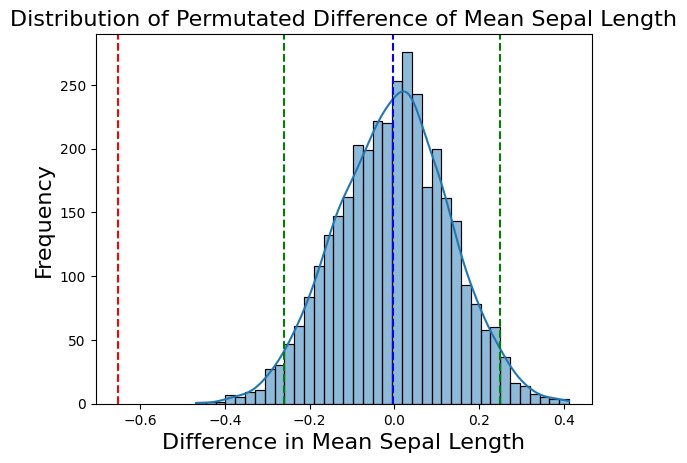

In [ ]:
combined_spec = np.concatenate([iris[iris["species"] == "versicolor"]["sepal_length"], iris[iris["species"] == "virginica"]["sepal_length"]])

simu_diff = []
samples = 3500
n_versicolor = len(iris[iris["species"] == "versicolor"]["sepal_length"])

for i in range(samples):
  perm_sample = np.random.permutation(combined_spec)
  perm_treatment = perm_sample[:n_versicolor]
  perm_control = perm_sample[n_versicolor:]
  perm_diff = np.mean(perm_treatment) - np.mean(perm_control)
  simu_diff.append(perm_diff)

lower = np.quantile(simu_diff, 0.025)
upper = np.quantile(simu_diff, 0.975)

print(lower, upper)

sns.histplot(simu_diff, kde=True)
plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color="blue", linestyle="--")
plt.axvline(x=difference, ymin=0, ymax=1, color="red", linestyle="--")
plt.title("Distribution of Permutated Difference of Mean Sepal Length", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.xlabel("Difference in Mean Sepal Length", fontsize=16)
plt.axvline(x=lower, ymin=0, ymax=1, color='green', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='green', linestyle='--')

## Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total
simulations)

Interpret the result at α = 0.05.

In [ ]:
p_value = np.sum(np.abs(simu_diff)>= np.abs(mean_diff))/5000
print(p_value)

0.0


## Questions

1.  What is the **null hypothesis (H0)** in this specific test?
2.  What does the **permutation distribution** represent in terms of
    **random chance**?
3.  Based on your p-value, do you **reject** or **fail to reject** the
    null hypothesis?

The null hypothesis is that there is no difference between the mean sepal lengths of versicolor and virginica. The permutation distribution shows the range of differences that could occur randomly. Since the p-value is less than 0.05 and the observed difference falls outside the 95% confidence interval, hence we reject the null hypothesis, indicating a significant difference between the species.